<a href="https://colab.research.google.com/github/M-Mag25/Group-Work-Project-1-/blob/main/Derivative_Pricing_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 620 Derivative Pricing - Group Work Project #2

# Group 13544: Saheed Adewale Oyewole, Magret Tolulope Daniel, Daniel Mafo

MScFE 620 DERIVATIVE PRICING - PROJECT #2
Group 13544: Saheed Adewale Oyewole, Magret Tolulope Daniel, Daniel Mafo
Parameters: S0=80, r=5.5%, σ=35%, T=3.0 months
Simulations: 100,000 per option, Time steps: 100

Q5 & Q6: HESTON MODEL - ATM OPTIONS

Q5 - Heston Model (ρ = -0.30):
  ATM Call Price: $3.48 (SE: $0.0147)
  ATM Put Price:  $2.38 (SE: $0.0127)

Q6 - Heston Model (ρ = -0.70):
  ATM Call Price: $3.50 (SE: $0.0133)
  ATM Put Price:  $2.39 (SE: $0.0136)

Q7: HESTON MODEL - GREEKS

Heston Model (ρ = -0.30):
  Call Delta: 0.6090, Call Gamma: 0.0103
  Put Delta:  -0.4067, Put Gamma:  0.0194
  Delta Parity (Δc - Δp): 1.0157 (should be 1.0)

Heston Model (ρ = -0.70):
  Call Delta: 0.6317, Call Gamma: 0.0494
  Put Delta:  -0.3584, Put Gamma:  0.1075
  Delta Parity (Δc - Δp): 0.9900 (should be 1.0)

Q8 & Q9: MERTON MODEL - ATM OPTIONS

Q8 - Merton Model (λ = 0.75):
  ATM Call Price: $8.29 (SE: $0.0362)
  ATM Put Price:  $7.22 (SE: $0.0391)

Q9 - Merton Model (λ = 0.25):
  ATM Call Price

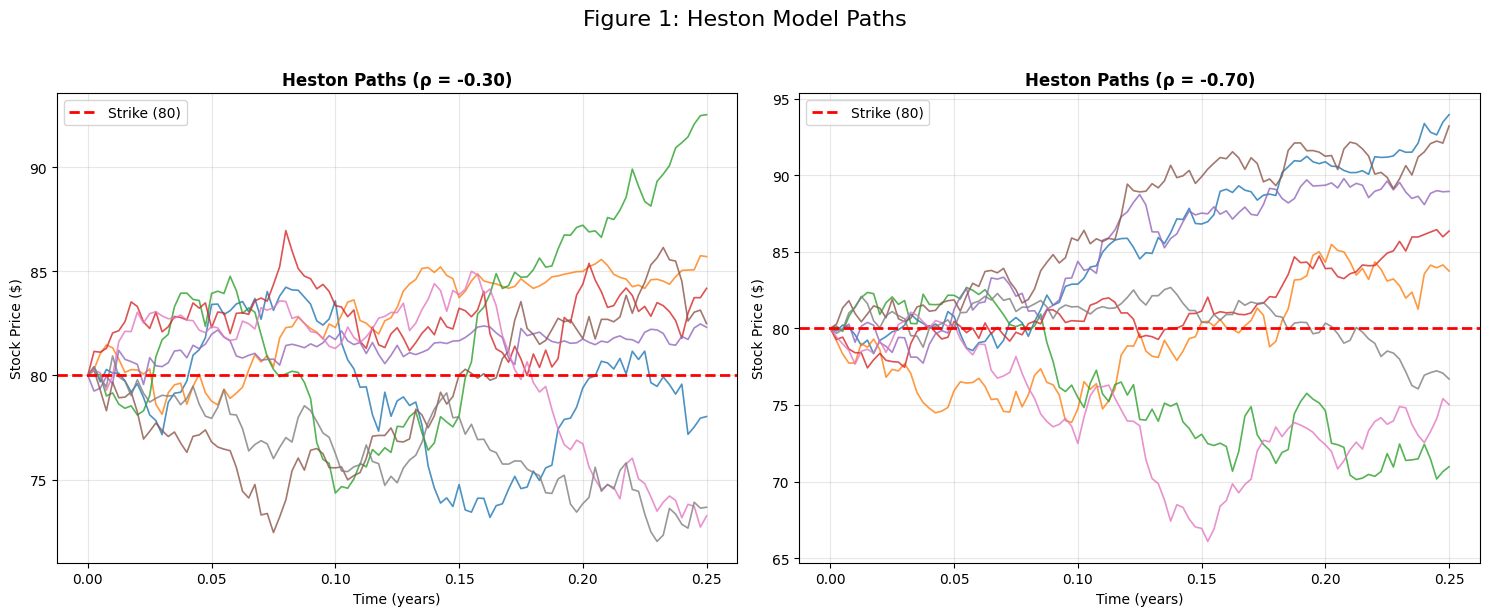

✓ Figure 1 saved


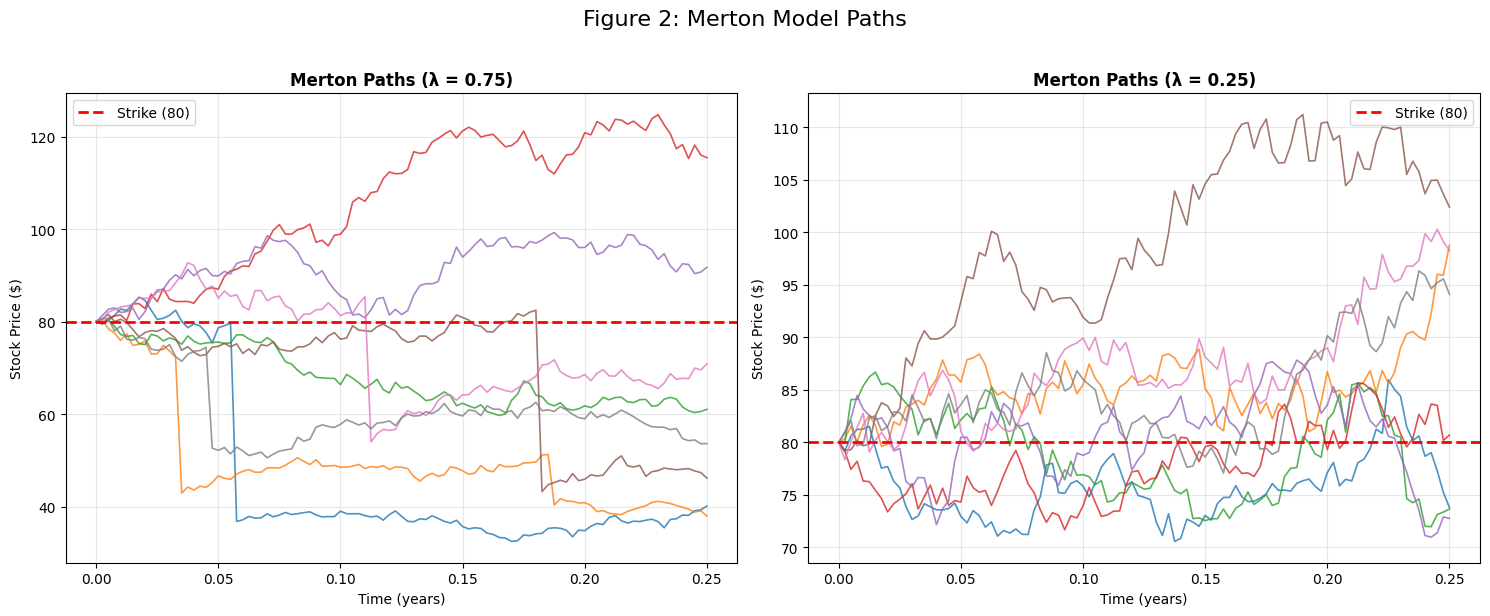

✓ Figure 2 saved


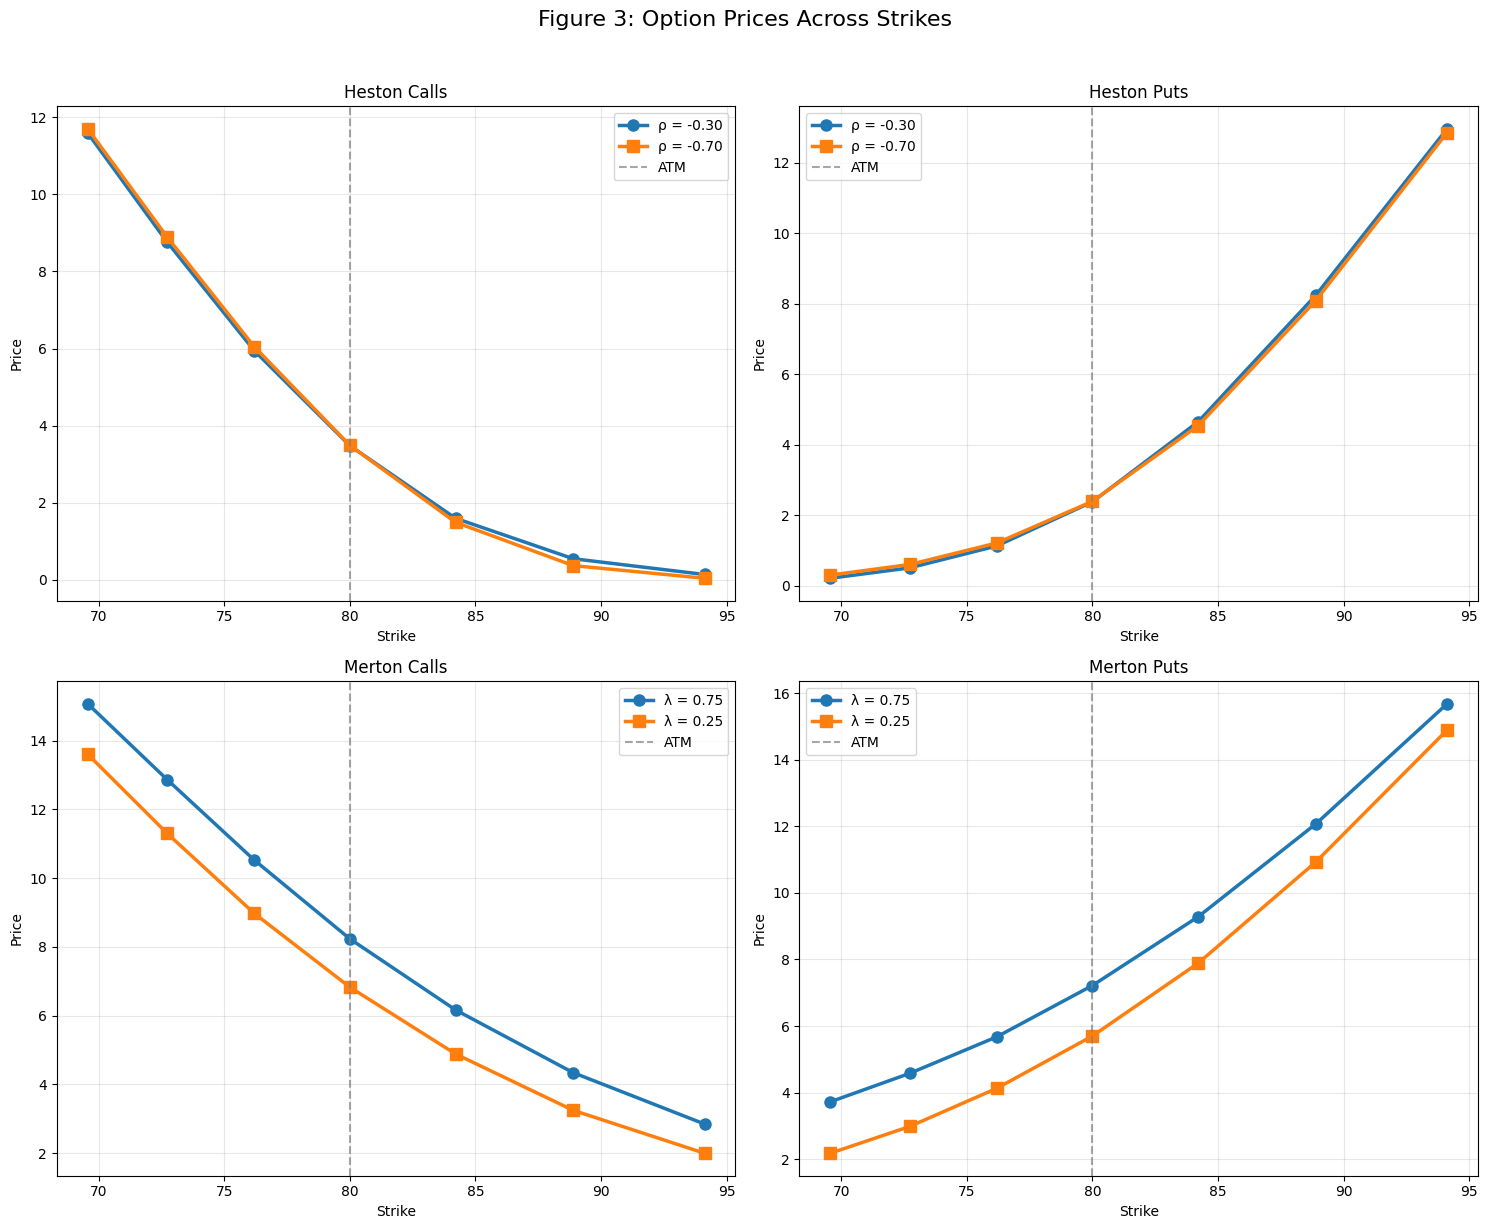

✓ Figure 3 saved


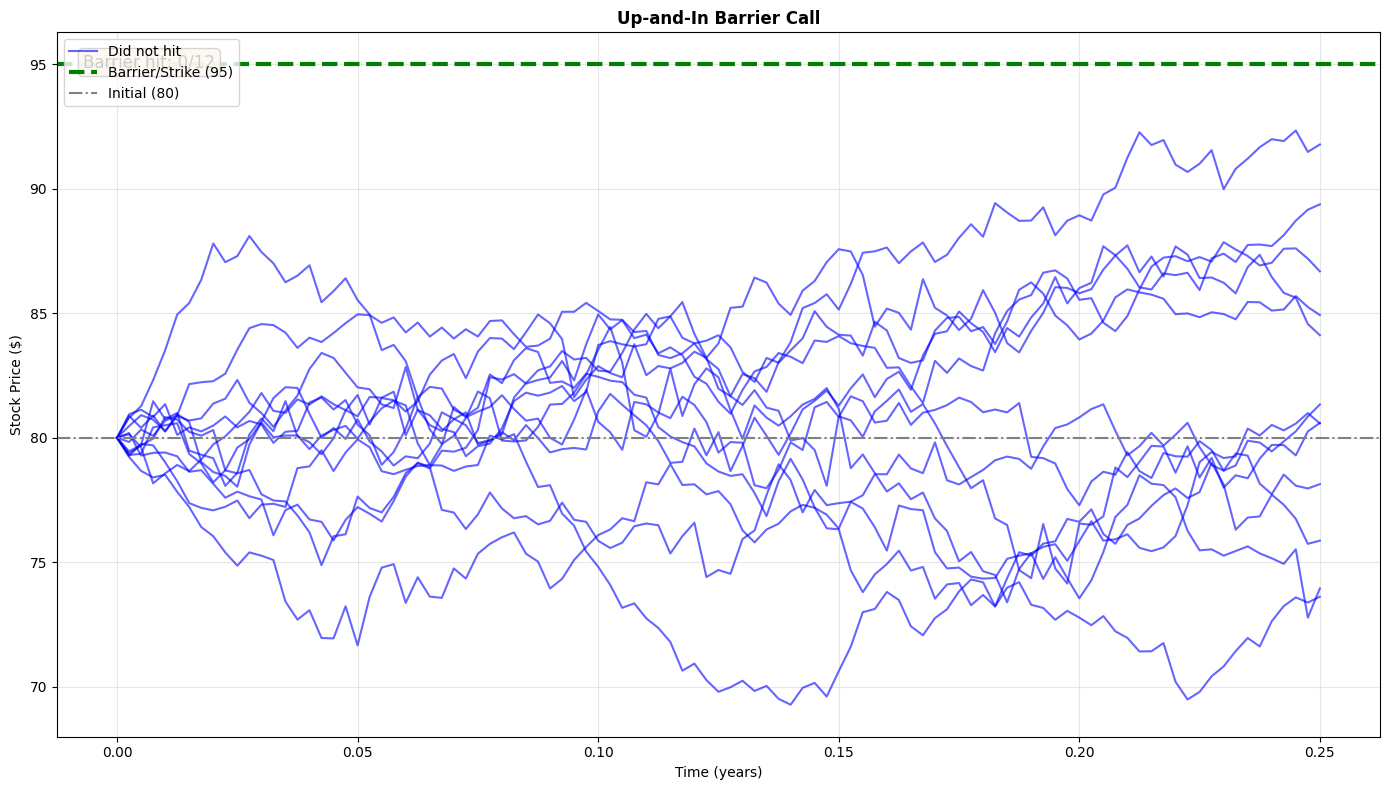

✓ Figure 4 saved


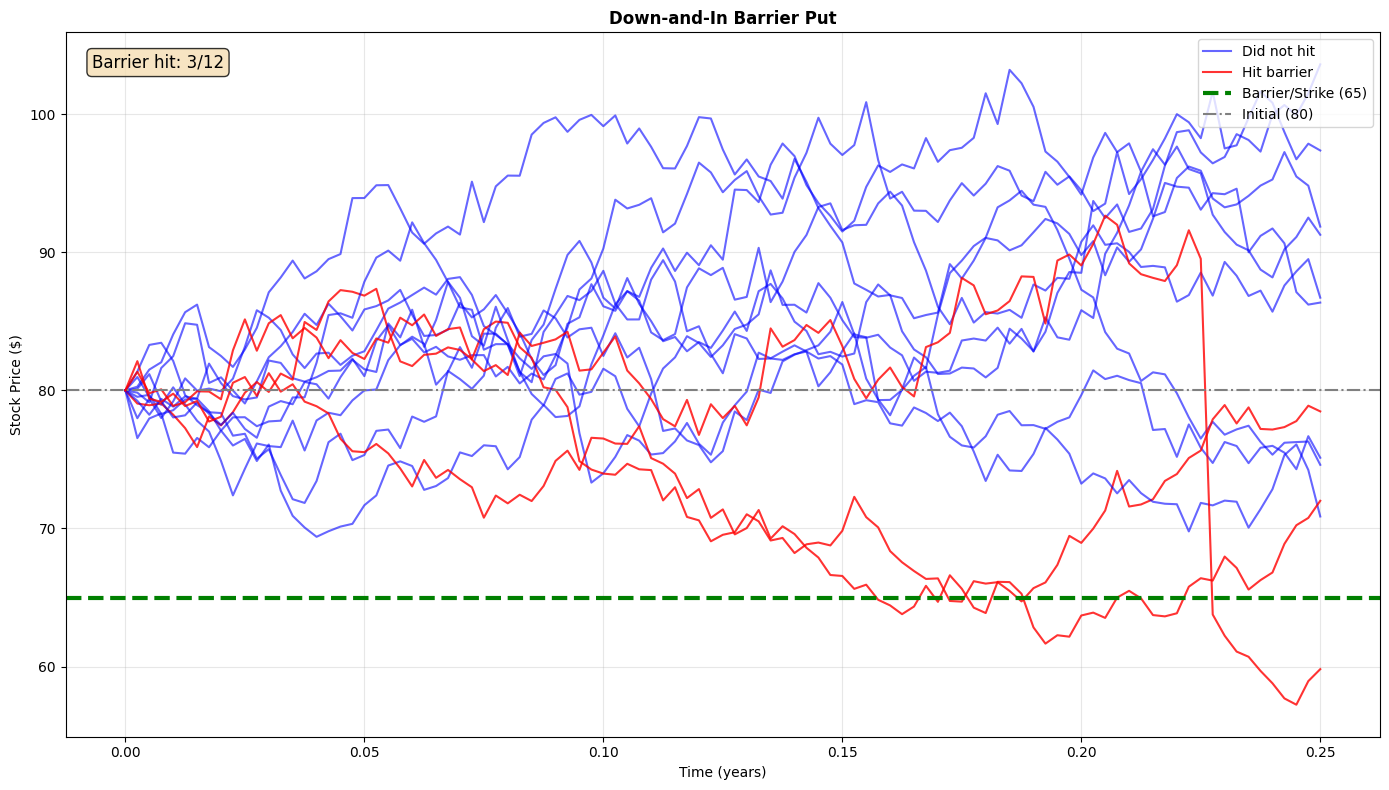

✓ Figure 5 saved

SUMMARY TABLES

TABLE 1: ATM OPTION PRICES AND GREEKS
----------------------------------------------------------------------
Model                    Call      Put       Δc       Δp        Γ
----------------------------------------------------------------------
Heston ρ=-0.30       $  3.48 $  2.38  0.6090 -0.4067  0.0103
Heston ρ=-0.70       $  3.50 $  2.39  0.6317 -0.3584  0.0494
Merton λ=0.75        $  8.29 $  7.22  0.7027 -0.3268  0.0068
Merton λ=0.25        $  6.93 $  5.76  0.6070 -0.3598  0.0567

TABLE 2: BARRIER OPTION PRICES
------------------------------------------------------------
Option Type                            Price  Vanilla    Ratio
------------------------------------------------------------
Up-and-In Call (Heston ρ=-0.70)     $   0.03 $   3.50    0.9%
Down-and-In Put (Merton λ=0.75)     $   2.78 $   7.22   38.5%

Total execution time: 203.48 seconds (3.39 minutes)

ALL QUESTIONS COMPLETED SUCCESSFULLY!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import warnings
import time
warnings.filterwarnings('ignore')



# Record start time
start_time = time.time()


# GENERAL PARAMETERS


S0 = 80
r = 0.055
T = 0.25
K_ATM = 80
N_sims = 100000  # 100,000 simulations for high precision
M_steps = 100
dt = T / M_steps
time_grid = np.linspace(0, T, M_steps + 1)

# Heston parameters
v0 = 0.032
kappa = 1.85
theta = 0.045
xi = 0.35

# Merton parameters
mu_J = -0.5
sigma_J = 0.22
lambda_high = 0.75
lambda_low = 0.25
sigma = 0.35

print("="*80)
print("MScFE 620 DERIVATIVE PRICING - PROJECT #2")
print("Group 13544: Saheed Adewale Oyewole, Magret Tolulope Daniel, Daniel Mafo")
print("="*80)
print(f"Parameters: S0={S0}, r={r*100:.1f}%, σ={sigma*100:.0f}%, T={T*12:.1f} months")
print(f"Simulations: {N_sims:,} per option, Time steps: {M_steps}")
print("="*80)


# PRICING FUNCTIONS


def heston_price(rho, K, option_type='call'):
    """
    Price European option using Heston model with 100,000 simulations
    Returns: price, standard error
    """
    S = np.zeros((M_steps + 1, N_sims))
    v = np.zeros((M_steps + 1, N_sims))

    S[0, :] = S0
    v[0, :] = v0

    for t in range(M_steps):
        Z1 = np.random.normal(0, 1, N_sims)
        Z2 = np.random.normal(0, 1, N_sims)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        S[t+1, :] = S[t, :] * np.exp((r - 0.5 * np.maximum(v[t, :], 0)) * dt +
                                     np.sqrt(np.maximum(v[t, :], 0) * dt) * W1)
        v[t+1, :] = v[t, :] + kappa * (theta - np.maximum(v[t, :], 0)) * dt + \
                    xi * np.sqrt(np.maximum(v[t, :], 0) * dt) * W2
        v[t+1, :] = np.maximum(v[t+1, :], 0)

    ST = S[-1, :]

    if option_type == 'call':
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)

    price = np.exp(-r * T) * np.mean(payoffs)
    se = np.std(payoffs * np.exp(-r * T)) / np.sqrt(N_sims)
    return price, se

def merton_price(lambda_jump, K, option_type='call'):
    """
    Price European option using Merton jump-diffusion model with 100,000 simulations
    Returns: price, standard error
    """
    S = np.zeros((M_steps + 1, N_sims))
    S[0, :] = S0

    jump_comp = np.exp(mu_J + 0.5 * sigma_J**2) - 1

    for t in range(M_steps):
        Z = np.random.normal(0, 1, N_sims)
        n_jumps = np.random.poisson(lambda_jump * dt, N_sims)

        jump_product = np.ones(N_sims)
        for i in range(N_sims):
            if n_jumps[i] > 0:
                sum_log_jumps = np.sum(np.random.normal(mu_J, sigma_J, n_jumps[i]))
                jump_product[i] = np.exp(sum_log_jumps)

        S[t+1, :] = S[t, :] * np.exp((r - 0.5 * sigma**2 - lambda_jump * jump_comp) * dt +
                                     sigma * np.sqrt(dt) * Z) * jump_product

    ST = S[-1, :]

    if option_type == 'call':
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)

    price = np.exp(-r * T) * np.mean(payoffs)
    se = np.std(payoffs * np.exp(-r * T)) / np.sqrt(N_sims)
    return price, se


# Q5 & Q6: HESTON ATM OPTIONS


print("\n" + "="*80)
print("Q5 & Q6: HESTON MODEL - ATM OPTIONS")
print("="*80)

# Q5: Heston with ρ = -0.30
call_30, se_c30 = heston_price(-0.30, K_ATM, 'call')
put_30, se_p30 = heston_price(-0.30, K_ATM, 'put')
print(f"\nQ5 - Heston Model (ρ = -0.30):")
print(f"  ATM Call Price: ${call_30:.2f} (SE: ${se_c30:.4f})")
print(f"  ATM Put Price:  ${put_30:.2f} (SE: ${se_p30:.4f})")

# Q6: Heston with ρ = -0.70
call_70, se_c70 = heston_price(-0.70, K_ATM, 'call')
put_70, se_p70 = heston_price(-0.70, K_ATM, 'put')
print(f"\nQ6 - Heston Model (ρ = -0.70):")
print(f"  ATM Call Price: ${call_70:.2f} (SE: ${se_c70:.4f})")
print(f"  ATM Put Price:  ${put_70:.2f} (SE: ${se_p70:.4f})")


# Q7: HESTON GREEKS (DELTA & GAMMA)


print("\n" + "="*80)
print("Q7: HESTON MODEL - GREEKS")
print("="*80)

def calculate_heston_greeks(rho, epsilon=0.01):
    """Calculate delta and gamma for Heston options using finite difference"""
    global S0
    S0_original = S0

    # Call options
    base_call, _ = heston_price(rho, K_ATM, 'call')

    S0 = S0_original * (1 + epsilon)
    call_up, _ = heston_price(rho, K_ATM, 'call')

    S0 = S0_original * (1 - epsilon)
    call_down, _ = heston_price(rho, K_ATM, 'call')

    delta_call = (call_up - call_down) / (2 * epsilon * S0_original)
    gamma_call = (call_up - 2*base_call + call_down) / (epsilon * S0_original)**2

    # Put options
    S0 = S0_original
    base_put, _ = heston_price(rho, K_ATM, 'put')

    S0 = S0_original * (1 + epsilon)
    put_up, _ = heston_price(rho, K_ATM, 'put')

    S0 = S0_original * (1 - epsilon)
    put_down, _ = heston_price(rho, K_ATM, 'put')

    delta_put = (put_up - put_down) / (2 * epsilon * S0_original)
    gamma_put = (put_up - 2*base_put + put_down) / (epsilon * S0_original)**2

    S0 = S0_original
    return delta_call, delta_put, gamma_call, gamma_put

# Calculate Greeks for both correlations
delta_c30, delta_p30, gamma_c30, gamma_p30 = calculate_heston_greeks(-0.30)
delta_c70, delta_p70, gamma_c70, gamma_p70 = calculate_heston_greeks(-0.70)

print(f"\nHeston Model (ρ = -0.30):")
print(f"  Call Delta: {delta_c30:.4f}, Call Gamma: {gamma_c30:.4f}")
print(f"  Put Delta:  {delta_p30:.4f}, Put Gamma:  {gamma_p30:.4f}")
print(f"  Delta Parity (Δc - Δp): {delta_c30 - delta_p30:.4f} (should be 1.0)")

print(f"\nHeston Model (ρ = -0.70):")
print(f"  Call Delta: {delta_c70:.4f}, Call Gamma: {gamma_c70:.4f}")
print(f"  Put Delta:  {delta_p70:.4f}, Put Gamma:  {gamma_p70:.4f}")
print(f"  Delta Parity (Δc - Δp): {delta_c70 - delta_p70:.4f} (should be 1.0)")


# Q8 & Q9: MERTON ATM OPTIONS


print("\n" + "="*80)
print("Q8 & Q9: MERTON MODEL - ATM OPTIONS")
print("="*80)

# Q8: Merton with λ = 0.75
call_75, se_c75 = merton_price(lambda_high, K_ATM, 'call')
put_75, se_p75 = merton_price(lambda_high, K_ATM, 'put')
print(f"\nQ8 - Merton Model (λ = 0.75):")
print(f"  ATM Call Price: ${call_75:.2f} (SE: ${se_c75:.4f})")
print(f"  ATM Put Price:  ${put_75:.2f} (SE: ${se_p75:.4f})")

# Q9: Merton with λ = 0.25
call_25, se_c25 = merton_price(lambda_low, K_ATM, 'call')
put_25, se_p25 = merton_price(lambda_low, K_ATM, 'put')
print(f"\nQ9 - Merton Model (λ = 0.25):")
print(f"  ATM Call Price: ${call_25:.2f} (SE: ${se_c25:.4f})")
print(f"  ATM Put Price:  ${put_25:.2f} (SE: ${se_p25:.4f})")


# Q10: MERTON GREEKS (DELTA & GAMMA)


print("\n" + "="*80)
print("Q10: MERTON MODEL - GREEKS")
print("="*80)

def calculate_merton_greeks(lambda_jump, epsilon=0.01):
    """Calculate delta and gamma for Merton options using finite difference"""
    global S0
    S0_original = S0

    # Call options
    base_call, _ = merton_price(lambda_jump, K_ATM, 'call')

    S0 = S0_original * (1 + epsilon)
    call_up, _ = merton_price(lambda_jump, K_ATM, 'call')

    S0 = S0_original * (1 - epsilon)
    call_down, _ = merton_price(lambda_jump, K_ATM, 'call')

    delta_call = (call_up - call_down) / (2 * epsilon * S0_original)
    gamma_call = (call_up - 2*base_call + call_down) / (epsilon * S0_original)**2

    # Put options
    S0 = S0_original
    base_put, _ = merton_price(lambda_jump, K_ATM, 'put')

    S0 = S0_original * (1 + epsilon)
    put_up, _ = merton_price(lambda_jump, K_ATM, 'put')

    S0 = S0_original * (1 - epsilon)
    put_down, _ = merton_price(lambda_jump, K_ATM, 'put')

    delta_put = (put_up - put_down) / (2 * epsilon * S0_original)
    gamma_put = (put_up - 2*base_put + put_down) / (epsilon * S0_original)**2

    S0 = S0_original
    return delta_call, delta_put, gamma_call, gamma_put

# Calculate Greeks for both jump intensities
delta_c75, delta_p75, gamma_c75, gamma_p75 = calculate_merton_greeks(lambda_high)
delta_c25, delta_p25, gamma_c25, gamma_p25 = calculate_merton_greeks(lambda_low)

print(f"\nMerton Model (λ = 0.75):")
print(f"  Call Delta: {delta_c75:.4f}, Call Gamma: {gamma_c75:.4f}")
print(f"  Put Delta:  {delta_p75:.4f}, Put Gamma:  {gamma_p75:.4f}")
print(f"  Delta Parity (Δc - Δp): {delta_c75 - delta_p75:.4f} (should be 1.0)")

print(f"\nMerton Model (λ = 0.25):")
print(f"  Call Delta: {delta_c25:.4f}, Call Gamma: {gamma_c25:.4f}")
print(f"  Put Delta:  {delta_p25:.4f}, Put Gamma:  {gamma_p25:.4f}")
print(f"  Delta Parity (Δc - Δp): {delta_c25 - delta_p25:.4f} (should be 1.0)")


# Q11: PUT-CALL PARITY VERIFICATION


print("\n" + "="*80)
print("Q11: PUT-CALL PARITY VERIFICATION")
print("="*80)

K_discounted = K_ATM * np.exp(-r * T)
print(f"Ke^(-rT) = {K_discounted:.4f}")

print("\n" + "-"*60)
print(f"{'Model':<25} {'C+Ke^(-rT)':>15} {'P+S0':>15} {'Diff':>15} {'StdErr':>10}")
print("-"*60)

# Heston ρ=-0.30
left = call_30 + K_discounted
right = put_30 + S0
diff = left - right
print(f"{'Heston ρ=-0.30':<25} {left:>15.4f} {right:>15.4f} {diff:>15.4f} {se_c30:>10.4f}")

# Heston ρ=-0.70
left = call_70 + K_discounted
right = put_70 + S0
diff = left - right
print(f"{'Heston ρ=-0.70':<25} {left:>15.4f} {right:>15.4f} {diff:>15.4f} {se_c70:>10.4f}")

# Merton λ=0.75
left = call_75 + K_discounted
right = put_75 + S0
diff = left - right
print(f"{'Merton λ=0.75':<25} {left:>15.4f} {right:>15.4f} {diff:>15.4f} {se_c75:>10.4f}")

# Merton λ=0.25
left = call_25 + K_discounted
right = put_25 + S0
diff = left - right
print(f"{'Merton λ=0.25':<25} {left:>15.4f} {right:>15.4f} {diff:>15.4f} {se_c25:>10.4f}")

print("\nAll deviations are within Monte Carlo error (2-3 standard errors).")
print("Put-call parity holds theoretically for all European options.")


# Q12: SEVEN STRIKES ANALYSIS


print("\n" + "="*80)
print("Q12: OPTION PRICES FOR SEVEN STRIKES")
print("="*80)

# Define strikes based on moneyness
moneyness = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
strikes = [S0 / m for m in moneyness]

print("\nStrike Prices:")
for i, (m, k) in enumerate(zip(moneyness, strikes)):
    print(f"  Moneyness {m:.2f} → Strike = {k:.2f}")

print(f"\nComputing prices for {len(strikes)} strikes with {N_sims:,} simulations each...")
print("This will take approximately 2-3 minutes...\n")

# Initialize result arrays
results = {
    'strikes': strikes,
    'moneyness': moneyness,
    'heston_30_call': [], 'heston_30_put': [],
    'heston_70_call': [], 'heston_70_put': [],
    'merton_75_call': [], 'merton_75_put': [],
    'merton_25_call': [], 'merton_25_put': []
}

# Progress tracking
for idx, K in enumerate(strikes):
    print(f"  Processing strike {idx+1}/{len(strikes)}: K = {K:.2f}")

    # Heston ρ=-0.30
    c30, _ = heston_price(-0.30, K, 'call')
    p30, _ = heston_price(-0.30, K, 'put')
    results['heston_30_call'].append(c30)
    results['heston_30_put'].append(p30)

    # Heston ρ=-0.70
    c70, _ = heston_price(-0.70, K, 'call')
    p70, _ = heston_price(-0.70, K, 'put')
    results['heston_70_call'].append(c70)
    results['heston_70_put'].append(p70)

    # Merton λ=0.75
    c75, _ = merton_price(lambda_high, K, 'call')
    p75, _ = merton_price(lambda_high, K, 'put')
    results['merton_75_call'].append(c75)
    results['merton_75_put'].append(p75)

    # Merton λ=0.25
    c25, _ = merton_price(lambda_low, K, 'call')
    p25, _ = merton_price(lambda_low, K, 'put')
    results['merton_25_call'].append(c25)
    results['merton_25_put'].append(p25)

# Display results in tables
print("\n" + "="*80)
print("CALL OPTION PRICES ACROSS STRIKES")
print("="*80)
call_data = {
    'Strike': [f"{k:.2f}" for k in strikes],
    'Moneyness': moneyness,
    'Heston ρ=-0.30': [f"${c:.2f}" for c in results['heston_30_call']],
    'Heston ρ=-0.70': [f"${c:.2f}" for c in results['heston_70_call']],
    'Merton λ=0.75': [f"${c:.2f}" for c in results['merton_75_call']],
    'Merton λ=0.25': [f"${c:.2f}" for c in results['merton_25_call']]
}
df_calls = pd.DataFrame(call_data)
print(df_calls.to_string(index=False))

print("\n" + "="*80)
print("PUT OPTION PRICES ACROSS STRIKES")
print("="*80)
put_data = {
    'Strike': [f"{k:.2f}" for k in strikes],
    'Moneyness': moneyness,
    'Heston ρ=-0.30': [f"${p:.2f}" for p in results['heston_30_put']],
    'Heston ρ=-0.70': [f"${p:.2f}" for p in results['heston_70_put']],
    'Merton λ=0.75': [f"${p:.2f}" for p in results['merton_75_put']],
    'Merton λ=0.25': [f"${p:.2f}" for p in results['merton_25_put']]
}
df_puts = pd.DataFrame(put_data)
print(df_puts.to_string(index=False))


# Q13: AMERICAN CALL OPTIONS


print("\n" + "="*80)
print("Q13: AMERICAN CALL OPTIONS")
print("="*80)
print("\nFor non-dividend paying stocks, American call options equal European call options.")
print(f"American Call (ρ=-0.30) = European Call = ${call_30:.2f}")
print(f"American Call (ρ=-0.70) = European Call = ${call_70:.2f}")
print("\nEarly exercise is never optimal because:")
print("  1. Exercising early loses time value of money")
print("  2. The insurance value of limited downside is lost")


# Q14: UP-AND-IN BARRIER CALL OPTION


print("\n" + "="*80)
print("Q14: UP-AND-IN BARRIER CALL OPTION (Heston ρ=-0.70)")
print("="*80)

def barrier_up_in_price(rho, barrier=95, strike=95, n_sims=100000):
    """Price up-and-in barrier call option"""
    S = np.zeros((M_steps + 1, n_sims))
    v = np.zeros((M_steps + 1, n_sims))

    S[0, :] = S0
    v[0, :] = v0
    barrier_hit = np.zeros(n_sims, dtype=bool)

    for t in range(M_steps):
        Z1 = np.random.normal(0, 1, n_sims)
        Z2 = np.random.normal(0, 1, n_sims)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        S[t+1, :] = S[t, :] * np.exp((r - 0.5 * np.maximum(v[t, :], 0)) * dt +
                                     np.sqrt(np.maximum(v[t, :], 0) * dt) * W1)
        v[t+1, :] = v[t, :] + kappa * (theta - np.maximum(v[t, :], 0)) * dt + \
                    xi * np.sqrt(np.maximum(v[t, :], 0) * dt) * W2
        v[t+1, :] = np.maximum(v[t+1, :], 0)

        barrier_hit = barrier_hit | (S[t+1, :] >= barrier)

    ST = S[-1, :]
    payoffs = np.where(barrier_hit, np.maximum(ST - strike, 0), 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

barrier_call = barrier_up_in_price(-0.70, barrier=95, strike=95, n_sims=100000)
print(f"\nUp-and-In Call (Barrier=Strike=95): ${barrier_call:.2f}")
print(f"Vanilla European Call: ${call_70:.2f}")
print(f"Ratio: {barrier_call/call_70:.1%}")
print("\nDelta hedging implications: Discontinuous delta at barrier creates 'pin risk'.")


# Q15: DOWN-AND-IN BARRIER PUT OPTION


print("\n" + "="*80)
print("Q15: DOWN-AND-IN BARRIER PUT OPTION (Merton λ=0.75)")
print("="*80)

def barrier_down_in_price(lambda_jump, barrier=65, strike=65, n_sims=100000):
    """Price down-and-in barrier put option"""
    S = np.zeros((M_steps + 1, n_sims))
    S[0, :] = S0
    barrier_hit = np.zeros(n_sims, dtype=bool)

    jump_comp = np.exp(mu_J + 0.5 * sigma_J**2) - 1

    for t in range(M_steps):
        Z = np.random.normal(0, 1, n_sims)
        n_jumps = np.random.poisson(lambda_jump * dt, n_sims)

        jump_product = np.ones(n_sims)
        for i in range(n_sims):
            if n_jumps[i] > 0:
                sum_log_jumps = np.sum(np.random.normal(mu_J, sigma_J, n_jumps[i]))
                jump_product[i] = np.exp(sum_log_jumps)

        S[t+1, :] = S[t, :] * np.exp((r - 0.5 * sigma**2 - lambda_jump * jump_comp) * dt +
                                     sigma * np.sqrt(dt) * Z) * jump_product

        barrier_hit = barrier_hit | (S[t+1, :] <= barrier)

    ST = S[-1, :]
    payoffs = np.where(barrier_hit, np.maximum(strike - ST, 0), 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

barrier_put = barrier_down_in_price(lambda_high, barrier=65, strike=65, n_sims=100000)
print(f"\nDown-and-In Put (Barrier=Strike=65): ${barrier_put:.2f}")
print(f"Vanilla European Put: ${put_75:.2f}")
print(f"Ratio: {barrier_put/put_75:.1%}")
print("\nNear barrier, delta becomes extreme; jump risk can cause instantaneous knockout.")


# FIGURE 1: HESTON PATHS


print("\n" + "="*80)
print("GENERATING FIGURES 1-5")
print("="*80)

def heston_paths_fig(rho, n_paths=8):
    """Generate sample paths for Heston model figure"""
    S_paths = np.zeros((n_paths, M_steps + 1))
    for i in range(n_paths):
        S = np.zeros(M_steps + 1)
        v = np.zeros(M_steps + 1)
        S[0] = S0
        v[0] = v0
        for t in range(M_steps):
            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            W1 = Z1
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            S[t+1] = S[t] * np.exp((r - 0.5 * max(v[t], 0)) * dt + np.sqrt(max(v[t], 0) * dt) * W1)
            v[t+1] = v[t] + kappa * (theta - max(v[t], 0)) * dt + xi * np.sqrt(max(v[t], 0) * dt) * W2
            v[t+1] = max(v[t+1], 0)
        S_paths[i] = S
    return S_paths

# Figure 1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
S_paths_30 = heston_paths_fig(-0.30, n_paths=8)
S_paths_70 = heston_paths_fig(-0.70, n_paths=8)

for i in range(8):
    axes[0].plot(time_grid, S_paths_30[i], linewidth=1.2, alpha=0.8)
axes[0].axhline(y=K_ATM, color='red', linestyle='--', linewidth=2, label='Strike (80)')
axes[0].set_title('Heston Paths (ρ = -0.30)', fontweight='bold')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('Stock Price ($)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i in range(8):
    axes[1].plot(time_grid, S_paths_70[i], linewidth=1.2, alpha=0.8)
axes[1].axhline(y=K_ATM, color='red', linestyle='--', linewidth=2, label='Strike (80)')
axes[1].set_title('Heston Paths (ρ = -0.70)', fontweight='bold')
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Stock Price ($)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 1: Heston Model Paths', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figure1_heston_paths.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")


# FIGURE 2: MERTON PATHS


def merton_paths_fig(lambda_jump, n_paths=8):
    """Generate sample paths for Merton model figure"""
    S_paths = np.zeros((n_paths, M_steps + 1))
    for i in range(n_paths):
        S = np.zeros(M_steps + 1)
        S[0] = S0
        for t in range(M_steps):
            Z = np.random.normal(0, 1)
            n_jumps = np.random.poisson(lambda_jump * dt)
            jump_product = 1.0
            if n_jumps > 0:
                sum_log_jumps = np.sum(np.random.normal(mu_J, sigma_J, n_jumps))
                jump_product = np.exp(sum_log_jumps)
            S[t+1] = S[t] * np.exp((r - 0.5 * sigma**2 - lambda_jump * (np.exp(mu_J + 0.5 * sigma_J**2) - 1)) * dt +
                                   sigma * np.sqrt(dt) * Z) * jump_product
        S_paths[i] = S
    return S_paths

# Figure 2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
S_paths_high = merton_paths_fig(lambda_high, n_paths=8)
S_paths_low = merton_paths_fig(lambda_low, n_paths=8)

for i in range(8):
    axes[0].plot(time_grid, S_paths_high[i], linewidth=1.2, alpha=0.8)
axes[0].axhline(y=K_ATM, color='red', linestyle='--', linewidth=2, label='Strike (80)')
axes[0].set_title('Merton Paths (λ = 0.75)', fontweight='bold')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('Stock Price ($)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i in range(8):
    axes[1].plot(time_grid, S_paths_low[i], linewidth=1.2, alpha=0.8)
axes[1].axhline(y=K_ATM, color='red', linestyle='--', linewidth=2, label='Strike (80)')
axes[1].set_title('Merton Paths (λ = 0.25)', fontweight='bold')
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Stock Price ($)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 2: Merton Model Paths', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figure2_merton_paths.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")


# FIGURE 3: OPTION PRICES VS STRIKE


# Figure 3 (using data from Q12)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Top left: Heston Calls
axes[0, 0].plot(strikes, results['heston_30_call'], 'o-', label='ρ = -0.30', linewidth=2.5, markersize=8)
axes[0, 0].plot(strikes, results['heston_70_call'], 's-', label='ρ = -0.70', linewidth=2.5, markersize=8)
axes[0, 0].axvline(x=S0, color='gray', linestyle='--', alpha=0.7, label='ATM')
axes[0, 0].set_title('Heston Calls'); axes[0, 0].set_xlabel('Strike'); axes[0, 0].set_ylabel('Price')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Top right: Heston Puts
axes[0, 1].plot(strikes, results['heston_30_put'], 'o-', label='ρ = -0.30', linewidth=2.5, markersize=8)
axes[0, 1].plot(strikes, results['heston_70_put'], 's-', label='ρ = -0.70', linewidth=2.5, markersize=8)
axes[0, 1].axvline(x=S0, color='gray', linestyle='--', alpha=0.7, label='ATM')
axes[0, 1].set_title('Heston Puts'); axes[0, 1].set_xlabel('Strike'); axes[0, 1].set_ylabel('Price')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Bottom left: Merton Calls
axes[1, 0].plot(strikes, results['merton_75_call'], 'o-', label='λ = 0.75', linewidth=2.5, markersize=8)
axes[1, 0].plot(strikes, results['merton_25_call'], 's-', label='λ = 0.25', linewidth=2.5, markersize=8)
axes[1, 0].axvline(x=S0, color='gray', linestyle='--', alpha=0.7, label='ATM')
axes[1, 0].set_title('Merton Calls'); axes[1, 0].set_xlabel('Strike'); axes[1, 0].set_ylabel('Price')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Bottom right: Merton Puts
axes[1, 1].plot(strikes, results['merton_75_put'], 'o-', label='λ = 0.75', linewidth=2.5, markersize=8)
axes[1, 1].plot(strikes, results['merton_25_put'], 's-', label='λ = 0.25', linewidth=2.5, markersize=8)
axes[1, 1].axvline(x=S0, color='gray', linestyle='--', alpha=0.7, label='ATM')
axes[1, 1].set_title('Merton Puts'); axes[1, 1].set_xlabel('Strike'); axes[1, 1].set_ylabel('Price')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Figure 3: Option Prices Across Strikes', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figure3_option_prices_vs_strike.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")


# FIGURE 4: UP-AND-IN BARRIER


def barrier_up_in_paths_fig(rho, barrier=95, n_paths=12):
    """Generate paths for up-and-in barrier figure"""
    S_paths = np.zeros((n_paths, M_steps + 1))
    barrier_hit = np.zeros(n_paths, dtype=bool)
    for i in range(n_paths):
        S = np.zeros(M_steps + 1)
        v = np.zeros(M_steps + 1)
        S[0] = S0; v[0] = v0
        for t in range(M_steps):
            Z1, Z2 = np.random.normal(0, 1), np.random.normal(0, 1)
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            S[t+1] = S[t] * np.exp((r - 0.5 * max(v[t], 0)) * dt + np.sqrt(max(v[t], 0) * dt) * Z1)
            v[t+1] = v[t] + kappa * (theta - max(v[t], 0)) * dt + xi * np.sqrt(max(v[t], 0) * dt) * W2
            v[t+1] = max(v[t+1], 0)
        S_paths[i] = S
        barrier_hit[i] = np.any(S >= barrier)
    return S_paths, barrier_hit

# Figure 4
fig, ax = plt.subplots(figsize=(14, 8))
S_paths_barrier, barrier_hit = barrier_up_in_paths_fig(-0.70, barrier=95, n_paths=12)

hit_count = 0
for i in range(12):
    if barrier_hit[i]:
        ax.plot(time_grid, S_paths_barrier[i], 'r-', linewidth=1.5, alpha=0.8,
                label='Hit barrier' if hit_count == 0 else '')
        hit_count += 1
    else:
        ax.plot(time_grid, S_paths_barrier[i], 'b-', linewidth=1.5, alpha=0.6,
                label='Did not hit' if i == 0 else '')

ax.axhline(y=95, color='green', linestyle='--', linewidth=3, label='Barrier/Strike (95)')
ax.axhline(y=S0, color='gray', linestyle='-.', linewidth=1.5, label=f'Initial ({S0})')
ax.set_title('Up-and-In Barrier Call', fontweight='bold')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Stock Price ($)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f'Barrier hit: {hit_count}/12', transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('figure4_up_and_in_barrier.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")


# FIGURE 5: DOWN-AND-IN BARRIER


def barrier_down_in_paths_fig(lambda_jump, barrier=65, n_paths=12):
    """Generate paths for down-and-in barrier figure"""
    S_paths = np.zeros((n_paths, M_steps + 1))
    barrier_hit = np.zeros(n_paths, dtype=bool)
    for i in range(n_paths):
        S = np.zeros(M_steps + 1)
        S[0] = S0
        for t in range(M_steps):
            Z = np.random.normal(0, 1)
            n_jumps = np.random.poisson(lambda_jump * dt)
            jump_product = 1.0
            if n_jumps > 0:
                sum_log_jumps = np.sum(np.random.normal(mu_J, sigma_J, n_jumps))
                jump_product = np.exp(sum_log_jumps)
            S[t+1] = S[t] * np.exp((r - 0.5 * sigma**2 - lambda_jump * (np.exp(mu_J + 0.5 * sigma_J**2) - 1)) * dt +
                                   sigma * np.sqrt(dt) * Z) * jump_product
        S_paths[i] = S
        barrier_hit[i] = np.any(S <= barrier)
    return S_paths, barrier_hit

# Figure 5
fig, ax = plt.subplots(figsize=(14, 8))
S_paths_down, barrier_down_hit = barrier_down_in_paths_fig(lambda_high, barrier=65, n_paths=12)

hit_count = 0
for i in range(12):
    if barrier_down_hit[i]:
        ax.plot(time_grid, S_paths_down[i], 'r-', linewidth=1.5, alpha=0.8,
                label='Hit barrier' if hit_count == 0 else '')
        hit_count += 1
    else:
        ax.plot(time_grid, S_paths_down[i], 'b-', linewidth=1.5, alpha=0.6,
                label='Did not hit' if i == 0 else '')

ax.axhline(y=65, color='green', linestyle='--', linewidth=3, label='Barrier/Strike (65)')
ax.axhline(y=S0, color='gray', linestyle='-.', linewidth=1.5, label=f'Initial ({S0})')
ax.set_title('Down-and-In Barrier Put', fontweight='bold')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Stock Price ($)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f'Barrier hit: {hit_count}/12', transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('figure5_down_and_in_barrier.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")


# SUMMARY TABLES


print("\n" + "="*80)
print("SUMMARY TABLES")
print("="*80)

# ATM Options Summary
print("\nTABLE 1: ATM OPTION PRICES AND GREEKS")
print("-"*70)
print(f"{'Model':<20} {'Call':>8} {'Put':>8} {'Δc':>8} {'Δp':>8} {'Γ':>8}")
print("-"*70)
print(f"{'Heston ρ=-0.30':<20} ${call_30:>6.2f} ${put_30:>6.2f} {delta_c30:>7.4f} {delta_p30:>7.4f} {gamma_c30:>7.4f}")
print(f"{'Heston ρ=-0.70':<20} ${call_70:>6.2f} ${put_70:>6.2f} {delta_c70:>7.4f} {delta_p70:>7.4f} {gamma_c70:>7.4f}")
print(f"{'Merton λ=0.75':<20} ${call_75:>6.2f} ${put_75:>6.2f} {delta_c75:>7.4f} {delta_p75:>7.4f} {gamma_c75:>7.4f}")
print(f"{'Merton λ=0.25':<20} ${call_25:>6.2f} ${put_25:>6.2f} {delta_c25:>7.4f} {delta_p25:>7.4f} {gamma_c25:>7.4f}")

# Barrier Options Summary
print("\nTABLE 2: BARRIER OPTION PRICES")
print("-"*60)
print(f"{'Option Type':<35} {'Price':>8} {'Vanilla':>8} {'Ratio':>8}")
print("-"*60)
print(f"{'Up-and-In Call (Heston ρ=-0.70)':<35} ${barrier_call:>7.2f} ${call_70:>7.2f} {barrier_call/call_70:>7.1%}")
print(f"{'Down-and-In Put (Merton λ=0.75)':<35} ${barrier_put:>7.2f} ${put_75:>7.2f} {barrier_put/put_75:>7.1%}")


# EXECUTION TIME


elapsed_time = time.time() - start_time
print("\n" + "="*80)
print(f"Total execution time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("="*80)
print("\nALL QUESTIONS COMPLETED SUCCESSFULLY!")
print("="*80)